<a href="https://colab.research.google.com/github/Timothy-John-Kaharian/CSST102-Activities/blob/main/CSST_102_Exercise_1_05_August_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Pipeline**

## **1. Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


## **2. Load and Understand the Dataset**

In [3]:
# Convert to Dataframe
df = pd.read_csv("iris.csv")

In [12]:
df.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
# Remove "Id" Column
df.drop(columns="Id", inplace=True)

KeyError: "['Id'] not found in axis"

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [16]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## **3. Visualize the Dataset**

Histogram

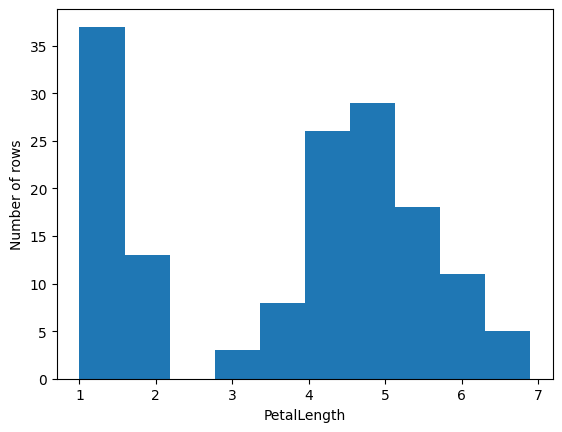

In [26]:
plt.hist(df["PetalLengthCm"])
plt.xlabel("PetalLength")
plt.ylabel("Number of rows")
plt.show()

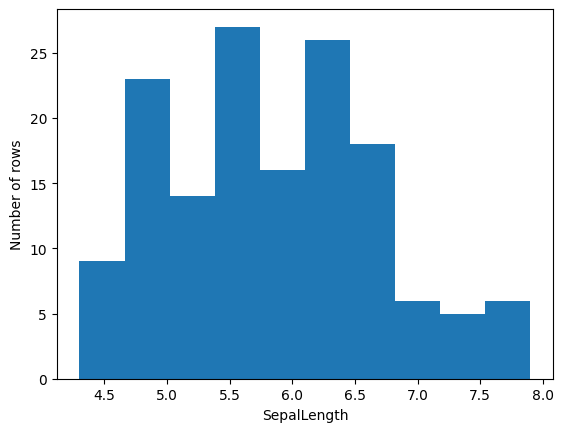

In [27]:
plt.hist(df["SepalLengthCm"])
plt.xlabel("SepalLength")
plt.ylabel("Number of rows")
plt.show()

Text(0.5, 1.0, 'petal_width')

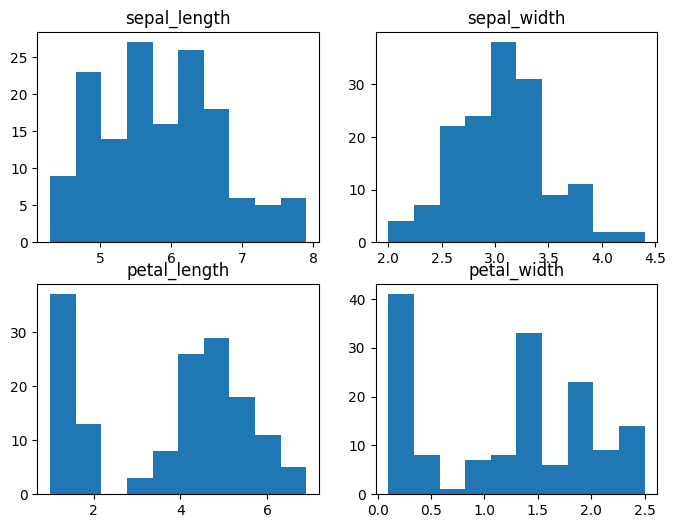

In [31]:
fig, ax = plt.subplots(2,2, figsize = (8,6))

ax[0,0].hist(df["SepalLengthCm"])
ax[0,1].hist(df["SepalWidthCm"])
ax[1,0].hist(df["PetalLengthCm"])
ax[1,1].hist(df["PetalWidthCm"])

ax[0,0].set_title("sepal_length")
ax[0,1].set_title("sepal_width")
ax[1,0].set_title("petal_length")
ax[1,1].set_title("petal_width")



Scatter Plot

In [32]:
colors = {"Iris-setosa":"red",
          "Iris-virginica":"blue",
          "Iris-versicolor":"green"}

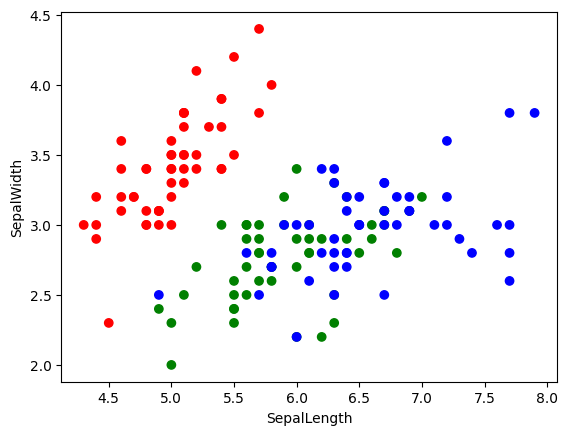

In [34]:
plt.scatter(df["SepalLengthCm"],
            df["SepalWidthCm"],
            c=df["Species"].map(colors))

plt.xlabel("SepalLength")
plt.ylabel("SepalWidth")
plt.show()

## **4. Split the Dataset into a Training Set and Testing Set**

In [36]:
# Features
X = df.drop(columns = ["Species"]).values

# Labels
y = df["Species"].values

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


## **5. Create the Model**

Choosing machine learning algorithm

In [39]:
knn = KNeighborsClassifier(n_neighbors=13)

Train the model

In [40]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13)

Test the model

In [41]:
y_pred = knn.predict(X_test)
metrics.accuracy_score(y_test, y_pred)


0.9666666666666667

## **6. Test the model (Prediction)**

In [45]:
knn.predict([[4, 2, 3, 2]])

array(['Iris-versicolor'], dtype=object)